<a href="https://colab.research.google.com/github/AlejandroAC977/KERAS---PRESION-SANGUINEA/blob/main/KERAS_LR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD

In [2]:
!pip install keras

In [11]:
from IPython.core.display import skip_doctest
data = pd.read_csv("/content/drive/MyDrive/dataset/dataset.csv", sep= ",", skiprows=32, usecols=[2, 3])
print(data)

    Age  Systolic blood pressure
0    39                      144
1    45                      138
2    47                      145
3    65                      162
4    46                      142
5    67                      170
6    42                      124
7    67                      158
8    56                      154
9    64                      162
10   56                      150
11   59                      140
12   34                      110
13   42                      128
14   48                      130
15   45                      135
16   17                      114
17   20                      116
18   19                      124
19   36                      136
20   50                      142
21   39                      120
22   21                      120
23   44                      160
24   53                      158
25   63                      144
26   29                      130
27   25                      125
28   69                      175


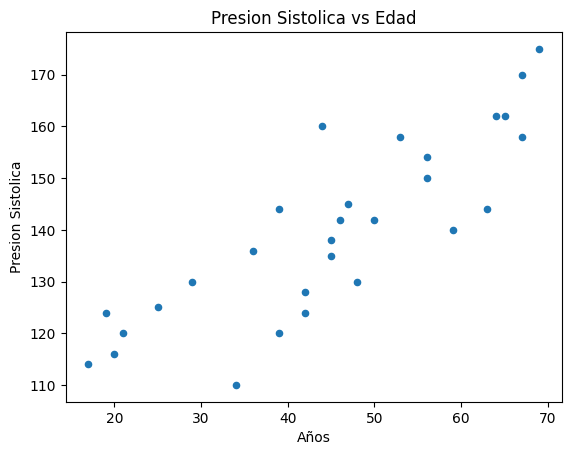

In [18]:
data.plot.scatter(x='Age', y='Systolic blood pressure')
plt.xlabel('Años')
plt.ylabel('Presion Sistolica')
plt.title('Presion Sistolica vs Edad')
plt.show()

In [19]:
x=data['Age'].values
y=data['Systolic blood pressure'].values

In [21]:
from keras.src.models import sequential
np.random.seed(2)

input_dim = 1
output_dim = 1
modelo = Sequential()
modelo.add(Dense(output_dim, input_dim=input_dim, activation='linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
sgd = SGD(learning_rate=0.0004)
modelo.compile(loss='mse', optimizer=sgd)

In [24]:
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
num_epoch=4000
batch_size=x.shape[0]
history=modelo.fit(x, y, epochs=num_epoch, batch_size=batch_size, verbose=0)

Parametros: w = 2.3, b = 27.4


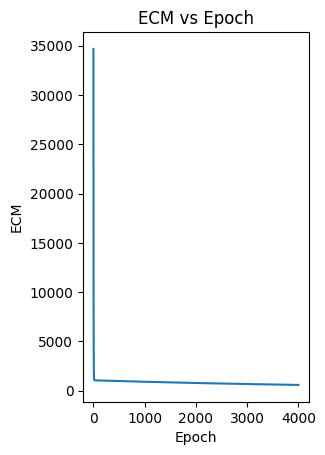

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


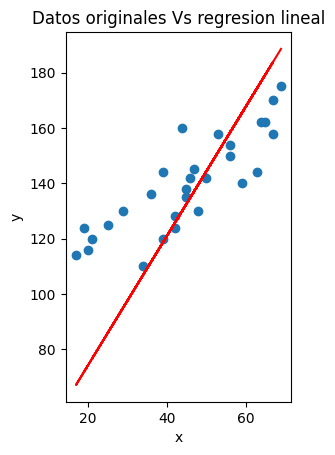

In [31]:
capas = modelo.layers[0]
w, b =  capas.get_weights()
print('Parametros: w = {:.1f}, b = {:.1f}'.format(w[0][0], b[0]))

plt.subplot(1,2,1)
plt.plot(history.history['loss'])
plt.xlabel('Epoch')
plt.ylabel('ECM')
plt.title('ECM vs Epoch')
plt.show()

y_regr = modelo.predict(x)
plt.subplot(1,2,1)
plt.scatter(x,y)
plt.plot(x, y_regr, color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Datos originales Vs regresion lineal')
plt.show()


In [32]:
x_pred = np.array([90])
y_pred = modelo.predict(x_pred)
print('Presion sanguinea sera {:.1f}'.format(y_pred[0][0]), 'para alguien de edad {:.1f}'.format(x_pred[0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Presion sanguinea sera 237.7 para alguien de edad 90.0
